# 03. churn_to_mvno baseline 분석

In [23]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier


In [24]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


In [25]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 서비스 가입 여부",
    "a03026_tminus1": "데이터 무제한 서비스 가입 여부",
    "c01002_tminus1": "월평균 휴대폰 이용 총 금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "휴대폰 결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))

In [26]:
# ============================================================
# 3. churn_to_mvno 분석용 데이터 구성
# ============================================================
# churn_to_mvno는 "메이저(1/2/3) -> MVNO(4)"만 1이므로,
# 해석상 전년 통신사가 메이저였던 사람들만 대상으로 보는 것이 자연스럽다.
#
# 단, 현재 저장된 데이터에 telco_tminus1 같은 컬럼이 없다면
# 전체 데이터에서 그대로 진행해야 한다.
# 여기서는 우선 현재 컬럼 기준으로 안전하게 진행한다.

target_col = "churn_to_mvno"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 누수 방지를 위해 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("churn_to_mvno 비율:", df[target_col].mean())
print("양성 개수:", df[target_col].sum())

사용 feature 개수: 10
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']
churn_to_mvno 비율: 0.012470035594082182
양성 개수: 515


In [27]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("양성 비율:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 10)
양성 비율: 0.012470035594082182
고유 pid 수: 10071


In [28]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train 양성 비율:", y_train.mean())
print("Test 양성 비율 :", y_test.mean())
print("Train 양성 개수:", y_train.sum())
print("Test 양성 개수 :", y_test.sum())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 10)
Test shape : (8307, 10)
Train 양성 비율: 0.013063773035887488
Test 양성 비율 : 0.010111953773925604
Train 양성 개수: 431
Test 양성 개수 : 84
겹치는 pid 수: 0


In [29]:
# ============================================================
# 6. 평가 함수
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

In [30]:
# ============================================================
# 7. Logistic Regression 학습
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [31]:
# ============================================================
# 8. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [32]:
# ============================================================
# 추가. Decision Tree / Gradient Boosting 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]


xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [33]:
# ============================================================
# 9. 성능 비교
# ============================================================
result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")
result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])
result_df = result_df.sort_values(["f1", "recall", "pr_auc"], ascending=False).reset_index(drop=True)
display(result_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.611051,0.014202,0.547619,0.027686,0.614490,0.018908
1,DecisionTree,0.618394,0.014169,0.535714,0.027607,0.592262,0.013365
2,RandomForest,0.975322,0.016000,0.023810,0.019139,0.615446,0.014433
3,GradientBoosting,0.989768,0.000000,0.000000,0.000000,0.643558,0.025239
4,XGBoost,0.989888,0.000000,0.000000,0.000000,0.638272,0.020732


In [34]:
# ============================================================
# 10. 상세 리포트 확인
# ============================================================
model_reports = [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb),
    ("XGBoost", y_pred_xgb)
]

for model_name, y_pred in model_reports:
    print(f"===== {model_name} | default threshold =====")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print()


===== Logistic Regression | default threshold =====
              precision    recall  f1-score   support

           0     0.9925    0.6117    0.7569      8223
           1     0.0142    0.5476    0.0277        84

    accuracy                         0.6111      8307
   macro avg     0.5034    0.5797    0.3923      8307
weighted avg     0.9826    0.6111    0.7495      8307

Confusion Matrix
[[5030 3193]
 [  38   46]]

===== Decision Tree | default threshold =====
              precision    recall  f1-score   support

           0     0.9924    0.6192    0.7626      8223
           1     0.0142    0.5357    0.0276        84

    accuracy                         0.6184      8307
   macro avg     0.5033    0.5775    0.3951      8307
weighted avg     0.9825    0.6184    0.7552      8307

Confusion Matrix
[[5092 3131]
 [  39   45]]

===== Random Forest | default threshold =====
              precision    recall  f1-score   support

           0     0.9900    0.9850    0.9875      8223
   

C:\Users\ch\anaconda3\envs\aistudy_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ch\anaconda3\envs\aistudy_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ch\anaconda3\envs\aistudy_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [35]:
# ============================================================
# 11. Logistic Regression 계수 확인
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = rename_feature_series(coef_df["feature"])
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))

,변수,계수,절대값
3,월평균 휴대폰 이용 총 금액,-0.429953,0.429953
1,음성 무제한 서비스 가입 여부,0.227867,0.227867
5,휴대폰 결합상품 가입 여부,-0.178129,0.178129
0,스마트폰 구분,-0.165666,0.165666
9,직업 유무,-0.144243,0.144243
6,휴대폰 요금 부담자,-0.134458,0.134458
4,월평균 기기 할부금,-0.089639,0.089639
2,데이터 무제한 서비스 가입 여부,0.088902,0.088902
8,개인 월평균 소득,0.062172,0.062172
7,나이,-0.048022,0.048022


In [36]:
# ============================================================
# 12. Random Forest 중요도 확인
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))

,변수,중요도
7,나이,0.356705
8,개인 월평균 소득,0.164654
3,월평균 휴대폰 이용 총 금액,0.158589
0,스마트폰 구분,0.076674
4,월평균 기기 할부금,0.067700
2,데이터 무제한 서비스 가입 여부,0.039037
1,음성 무제한 서비스 가입 여부,0.038187
5,휴대폰 결합상품 가입 여부,0.037638
6,휴대폰 요금 부담자,0.036318
9,직업 유무,0.024497


,feature_label,importance
8,개인 월평균 소득,0.214312
7,나이,0.195312
3,월평균 휴대폰 이용 총 금액,0.194674
0,스마트폰 구분,0.098587
4,월평균 기기 할부금,0.082507
2,데이터 무제한 서비스 가입 여부,0.049574
5,휴대폰 결합상품 가입 여부,0.046779
1,음성 무제한 서비스 가입 여부,0.045282
6,휴대폰 요금 부담자,0.042946
9,직업 유무,0.030028


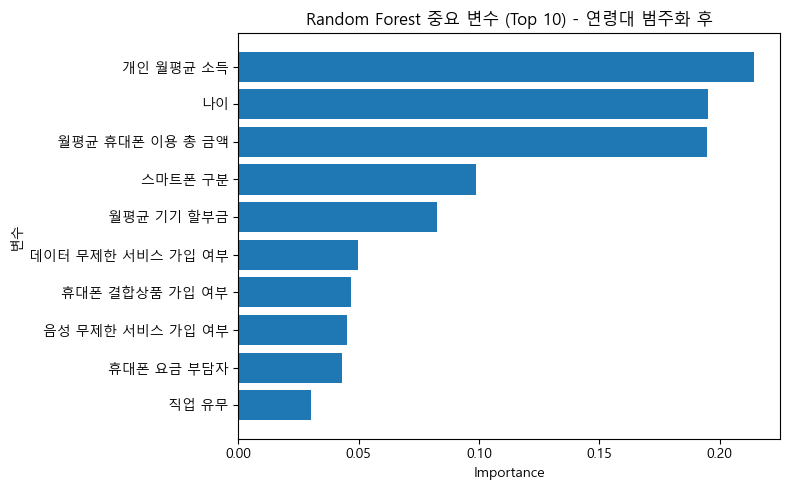

In [37]:
# ============================================================
# 12-1. Random Forest 중요도 확인
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

X_train_binned = X_train.copy()
X_test_binned = X_test.copy()

X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10
X_test_binned['age1_tminus1'] = (X_test_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]

importance_binned_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model_binned.feature_importances_
})

importance_binned_df["feature_label"] = rename_feature_series(importance_binned_df["feature"])
importance_binned_df = importance_binned_df.sort_values("importance", ascending=False)

display(importance_binned_df[["feature_label", "importance"]].head(15))

top_n = 10
plot_df = importance_binned_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 후")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

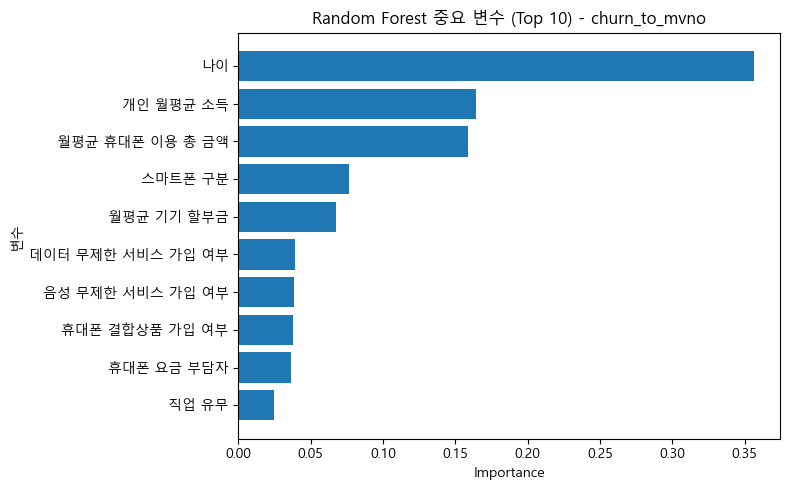

In [38]:
# ============================================================
# 13. 중요 변수 시각화
# ============================================================
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - churn_to_mvno")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()


,feature_label,importance
8,개인 월평균 소득,0.214312
7,나이,0.195312
3,월평균 휴대폰 이용 총 금액,0.194674
0,스마트폰 구분,0.098587
4,월평균 기기 할부금,0.082507
2,데이터 무제한 서비스 가입 여부,0.049574
5,휴대폰 결합상품 가입 여부,0.046779
1,음성 무제한 서비스 가입 여부,0.045282
6,휴대폰 요금 부담자,0.042946
9,직업 유무,0.030028


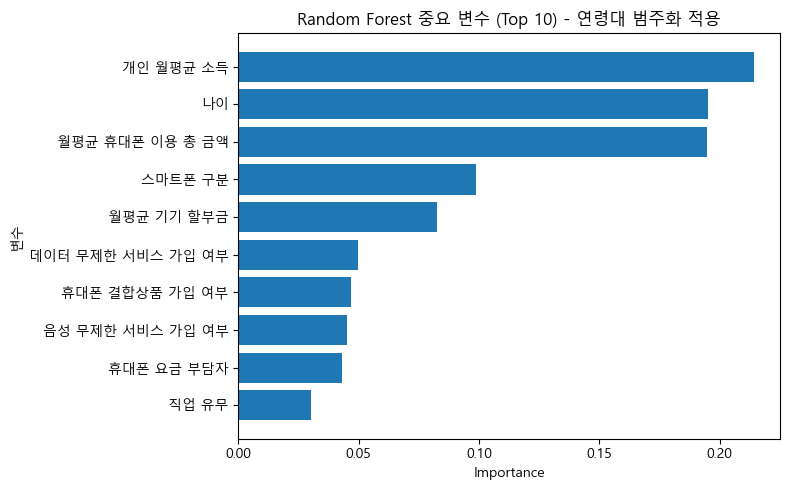

In [39]:
# ============================================================
# 13-1. 중요 변수 시각화
# ============================================================

X_train_binned = X_train.copy()
X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model_binned.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

display(importance_df[["feature_label", "importance"]].head(15))

top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 적용")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

,threshold,precision,recall,f1
0,0.05,0.010112,1.000000,0.020021
1,0.10,0.010113,1.000000,0.020024
2,0.15,0.010160,1.000000,0.020115
3,0.20,0.010289,1.000000,0.020369
4,0.25,0.010567,1.000000,0.020914
5,0.30,0.010864,0.976190,0.021488
6,0.35,0.011035,0.904762,0.021805
7,0.40,0.011610,0.797619,0.022886
8,0.45,0.013053,0.702381,0.025630
9,0.50,0.014202,0.547619,0.027686


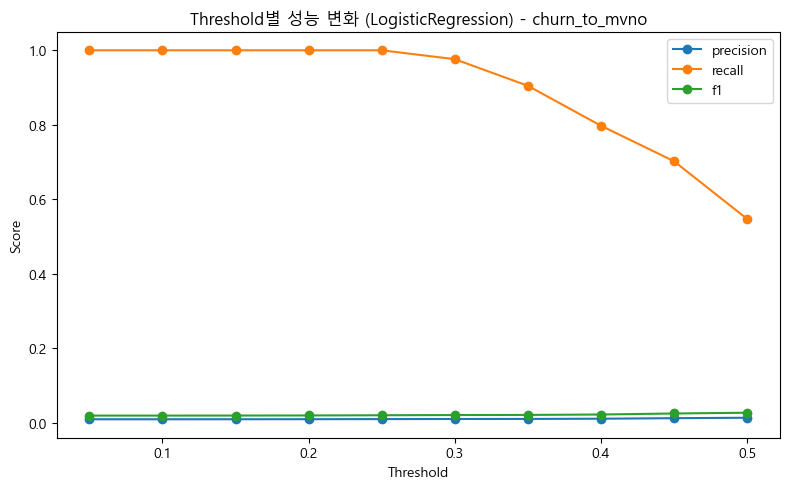

In [40]:
# ============================================================
# 추가. Logistic Regression threshold 조정
# ============================================================
def evaluate_by_threshold(y_true, y_proba, thresholds):
    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

thresholds = np.arange(0.05, 0.51, 0.05)
threshold_df = evaluate_by_threshold(y_test, y_proba_log, thresholds)

display(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.title("Threshold별 성능 변화 (LogisticRegression) - churn_to_mvno")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


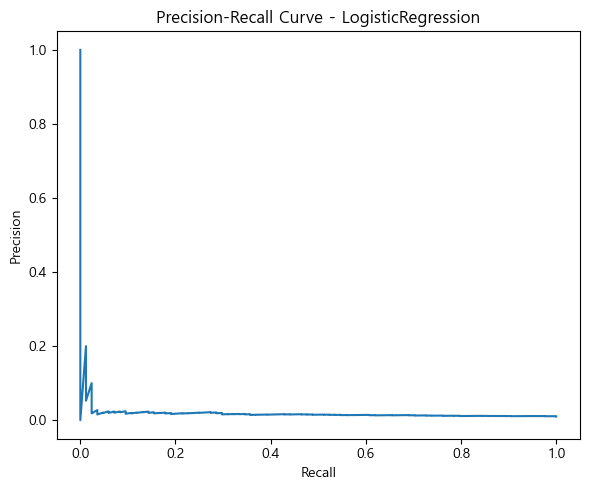

In [41]:
# ============================================================
# 추가. Precision-Recall Curve
# ============================================================
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_proba_log)

plt.figure(figsize=(6, 5))
plt.plot(recall_arr, precision_arr)
plt.title("Precision-Recall Curve - LogisticRegression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


In [42]:
# ============================================================
# 추가. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]

xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = rename_feature_series(xgb_importance_df["feature"])
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))

,변수,중요도
3,월평균 휴대폰 이용 총 금액,0.118601
6,휴대폰 요금 부담자,0.109762
8,개인 월평균 소득,0.109030
5,휴대폰 결합상품 가입 여부,0.108719
1,음성 무제한 서비스 가입 여부,0.108090
7,나이,0.097959
2,데이터 무제한 서비스 가입 여부,0.092396
4,월평균 기기 할부금,0.091483
0,스마트폰 구분,0.090164
9,직업 유무,0.073796


In [43]:
# ============================================================
# 추가. F1 스코어 극대화를 위한 최적 임계값 자동 탐색기
# ============================================================

from sklearn.metrics import precision_recall_curve, classification_report

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_log)

# precision_recall_curve의 precisions/recalls는 thresholds보다 길이가 1 더 길다.
# 따라서 threshold와 정확히 대응되는 구간만 사용해 F1을 계산한다.
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = f1_scores[optimal_idx]

print(f"최적의 임계값 (Optimal Threshold): {optimal_threshold:.4f}")
print(f"최고 F1 스코어 (Max F1 Score): {max_f1:.4f}")

y_pred_optimal = (y_proba_log >= optimal_threshold).astype(int)

print("\n[ 최적 임계값 적용 후 분류 리포트 ]")
print(classification_report(y_test, y_pred_optimal, digits=4))


최적의 임계값 (Optimal Threshold): 0.6111
최고 F1 스코어 (Max F1 Score): 0.0402

[ 최적 임계값 적용 후 분류 리포트 ]
              precision    recall  f1-score   support

           0     0.9916    0.8739    0.9290      8223
           1     0.0217    0.2738    0.0402        84

    accuracy                         0.8678      8307
   macro avg     0.5066    0.5738    0.4846      8307
weighted avg     0.9818    0.8678    0.9200      8307



---

### F1 최적 임계값(Optimal Threshold) 탐색의 한계

불균형 데이터의 한계를 확인하기 위해 `LogisticRegression` 예측 확률에 대해  
F1 스코어가 최대가 되는 임계값을 탐색하는 실험을 진행하였다.

이 실험은 threshold 조정이 어느 정도까지 성능을 보완할 수 있는지 확인하기 위한 보조 분석이다.  
다만 최고 F1 자체가 여전히 매우 낮은 수준에 머물렀다면,
이는 단순 threshold 조정만으로는 희소 클래스 문제의 근본적 한계를 넘기 어렵다는 뜻으로 해석하는 것이 적절하다.

즉 threshold 조정은 운영 목적에 맞춰 정밀도와 재현율의 균형을 조절하는 수단일 수는 있지만,
현재와 같은 극단적 불균형 환경에서는 구조적인 성능 개선을 보장하지는 않는다.

---

In [44]:
# ============================================================
# 추가. 이지 앙상블(EasyEnsemble)
# ============================================================

from imblearn.ensemble import EasyEnsembleClassifier

ee_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", EasyEnsembleClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ))
])

ee_pipe.fit(X_train.values, y_train.values)

y_pred_ee = ee_pipe.predict(X_test.values)
y_proba_ee = ee_pipe.predict_proba(X_test.values)[:, 1]

---

### 이지 앙상블(EasyEnsemble)

본 실험에서는 극심한 클래스 불균형 상황에서의 보완 가능성을 확인하기 위해  
`EasyEnsemble`도 추가 실험으로 적용해 보았다.

이 결과는 `03`의 baseline 자체를 대체하는 최종 결론이 아니라,
현재 변수와 라벨 구조에서 불균형 특화 기법이 어느 정도 방향성을 줄 수 있는지 확인하는 참고용 결과로 해석하는 것이 적절하다.

즉 `churn_to_mvno`의 핵심 메시지는
baseline에서 희소 라벨 한계를 확인했고, threshold 조정과 불균형 특화 기법을 검토했지만
근본적으로는 데이터 희소성과 변수 한계가 크다는 점에 있다.

---

In [45]:
# 이지 앙상블 결과 계산
result_ee = evaluate_binary_classifier(y_test, y_pred_ee, y_proba_ee, "EasyEnsemble")

# 기존 결과 데이터프레임이 있다면 합쳐서 비교
# result_df가 없다면 pd.DataFrame([result_ee])로 시작해봐
result_df = pd.concat([result_df, pd.DataFrame([result_ee])]).drop_duplicates(subset=['model'], keep='last')
display(result_df.sort_values("pr_auc", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
3,GradientBoosting,0.989768,0.000000,0.000000,0.000000,0.643558,0.025239
4,XGBoost,0.989888,0.000000,0.000000,0.000000,0.638272,0.020732
0,EasyEnsemble,0.626821,0.016046,0.595238,0.031250,0.648043,0.020446
0,LogisticRegression,0.611051,0.014202,0.547619,0.027686,0.614490,0.018908
2,RandomForest,0.975322,0.016000,0.023810,0.019139,0.615446,0.014433
1,DecisionTree,0.618394,0.014169,0.535714,0.027607,0.592262,0.013365


## [ 결과 해석 ]

### 1. `churn_to_mvno` baseline 모델 비교 해석

`churn_to_mvno`는 테스트 셋 기준 양성 비율이 약 `1.01%` 수준으로 매우 낮은 극심한 희소 클래스 문제다.
따라서 Accuracy보다 실제 이탈자를 놓치지 않는 `Recall`, 그리고 `F1`, `PR-AUC`를 중심으로 해석하는 것이 적절하다.

초기 baseline 비교 결과에서는 `LogisticRegression`과 `DecisionTree`가 실제 양성을 상대적으로 더 많이 탐지했다.

`LogisticRegression`은 Recall `0.5476`, F1 `0.0277`, ROC-AUC `0.6145`, PR-AUC `0.0189`를 기록하였다.
Recall과 F1 기준에서 가장 안정적인 baseline으로 볼 수 있었고,
희소 클래스 환경에서도 실제 양성을 일정 수준 포착하는 기준선 모델 역할을 수행하였다.

`DecisionTree`도 Recall `0.5357`, F1 `0.0276`으로 `LogisticRegression`과 유사한 탐지 성향을 보였다.
다만 ROC-AUC `0.5923`, PR-AUC `0.0134`로 전반적 확률 분리 성능은 `LogisticRegression`보다 다소 낮았다.

반면 `RandomForest`는 Accuracy `0.9753`으로 매우 높게 보였지만, Recall `0.0238`, F1 `0.0191`에 그쳤다.
즉 대부분을 음성으로 예측해 정확도는 높지만 실제 알뜰폰 이동자를 거의 잡지 못하는 구조에 가까웠다.

`GradientBoosting`과 `XGBoost`는 기본 설정에서 양성 예측을 거의 수행하지 못해 Recall과 F1이 사실상 0에 가까웠다.
따라서 현재처럼 양성 비율이 극단적으로 낮은 문제에서는 복잡한 부스팅 계열이 baseline에서 바로 강점을 보이지 못했다.

정리하면 이번 baseline에서는 `LogisticRegression`이 가장 안정적인 기준선 역할을 했고,
`DecisionTree`는 유사한 탐지형 대안으로 볼 수 있었다.
반면 `RandomForest`, `GradientBoosting`, `XGBoost`는 기본 설정 기준으로 실제 양성 탐지력이 매우 약했다.

### 2. 희소 클래스와 threshold 조정의 한계

희소 클래스 문제를 보완하기 위해 `LogisticRegression`의 예측 확률에 대해 threshold를 조정하는 실험을 진행했다.
threshold를 바꾸면 Recall과 Precision 사이의 trade-off가 크게 움직이는 것이 확인되었다.

다만 F1 기준 최적 threshold를 적용해도 최고 F1은 `0.0402` 수준에 머물렀다.
즉 threshold 조정은 운영 목적에 맞춰 탐지 성향을 조절하는 수단일 수는 있지만,
현재와 같은 1% 수준 희소 문제를 근본적으로 해결하는 방법은 아니었다.

### 3. 변수 해석

이번 분석에서는 비용 관련 변수와 개인 배경 변수가 알뜰폰 이동 예측에서 의미 있는 신호로 나타날 가능성을 확인했다.
특히 `개인 월평균 소득`, `나이`, `월평균 휴대폰 이용 총 금액`은
트리 계열 모델 중요도에서 반복적으로 상위권에 나타났다.

이는 단순히 "요금이 비싸서 이동한다"는 단일 설명보다,
개인의 경제적 여건과 생애주기, 실제 요금 부담이 함께 작용할 가능성을 시사한다.

다만 이 해석은 희소 라벨 baseline 결과에 기반한 것이므로,
강한 인과 해석보다는 "유력한 설명 후보" 수준으로 정리하는 것이 적절하다.

### 4. 추가 실험과 종합 해석

threshold 조정과 `EasyEnsemble` 같은 불균형 대응 기법도 함께 확인해 보았지만,
현재 데이터 구조에서는 Recall 일부 개선은 가능했지만 Precision과 F1은 여전히 낮아 실무 활용에는 한계가 컸다.

`EasyEnsemble`은 Recall `0.5952`, F1 `0.0313`으로 baseline 대비 일부 보완 가능성을 보여 주었지만,
이 역시 정밀도가 매우 낮아 실제 운영 단계에서 바로 활용하기에는 부담이 큰 결과였다.

따라서 `churn_to_mvno` 문제는
어떤 단일 모델이 정답이라기보다,
극심한 클래스 불균형 자체가 가장 큰 난점이며
추가 행동 변수, 계약 정보, 시계열 변화량 같은 더 직접적인 신호가 필요하다는 점을 시사한다고 정리할 수 있다.

---

## [ 03_churn_to_mvno 모델링의 핵심 한계점 ]

### 1. 극단적인 클래스 불균형

이 문제의 가장 큰 한계는 타겟(알뜰폰 이동자)의 수가 매우 적다는 점이다.

- 테스트 셋 8,307명 중 실제 양성은 84명(약 1.01%)에 불과하다.
- 이 때문에 정확도는 높게 보여도 실제 양성을 놓치는 모델이 쉽게 나타날 수 있다.
- `RandomForest`, `GradientBoosting`, `XGBoost`는 기본 설정에서는 대부분을 음성으로 예측하는 경향을 보였고, 특히 `GradientBoosting`과 `XGBoost`는 테스트 셋에서 양성을 거의 예측하지 못했다.
- `EasyEnsemble`과 같은 불균형 대응 기법을 적용하더라도, 원본 데이터 자체의 정보량 부족을 완전히 해결하기는 어렵다.

### 2. 변수 정보의 한계와 높은 오탐 가능성

threshold를 낮추거나 불균형 대응 기법을 적용하면 Recall을 높일 수는 있었지만,
Precision은 여전히 매우 낮은 수준에 머물렀다.

- 최적화 이후에도 F1-Score는 대체로 `0.02 ~ 0.05` 수준에 머물렀다.
- 이는 현재 사용한 변수만으로는 이탈자와 비이탈자를 충분히 뚜렷하게 구분하기 어렵다는 뜻에 가깝다.
- 실제로 84명의 양성과 다수의 음성 고객은 인구통계학적·경제적 특성이 상당 부분 겹칠 수 있다.
- 약정 만료 여부, 단말기 할부 상태, 최근 사용량 변화 같은 직접적 트리거 변수가 없다는 점도 한계다.

### 3. 정적 시점 기반 예측의 한계

현재 분석은 `_tminus1` 시점의 정적 상태값을 사용한다.

- 즉 "이전 해에 어떤 상태였는가"는 반영하지만,
- "최근 몇 개월 동안 어떻게 변했는가" 같은 시계열적 변화는 반영하지 못한다.
- 통신사 이동은 누적된 불만이나 급격한 상황 변화로 발생할 수 있기 때문에,
  변화량 정보가 없으면 실제 이동 타이밍을 정확하게 포착하는 데 한계가 있다.

---